# Perbandingan CNN From Scratch dan Transfer Learning untuk Klasifikasi Citra

## Tugas Individu Pembelajaran Mesin 2

**Nama:** Zahra Arayanindra Arum Samudra

**NIM:** 452024618068

**Prodi:** Teknik Informatika

---

## Deskripsi Tugas

Pada tugas ini dilakukan perbandingan dua pendekatan Deep Learning untuk klasifikasi citra, yaitu:

1. CNN From Scratch
2. Transfer Learning menggunakan MobileNetV2

Eksperimen dilakukan untuk mengetahui perbedaan performa, waktu training, risiko overfitting, dan efektivitas masing-masing metode dalam menyelesaikan masalah klasifikasi citra.

# Eksperimen 1 : CNN From Scratch

Dataset yang digunakan adalah CIFAR-10.

Dari 10 kelas yang tersedia, hanya digunakan dua kelas:

- Cat (label 3)
- Dog (label 5)

Tujuan eksperimen ini adalah membangun model CNN dari awal tanpa menggunakan pretrained model.

In [27]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Memuat Dataset CIFAR-10

Dataset CIFAR-10 terdiri dari 60.000 gambar berukuran 32x32 piksel.

Pada penelitian ini hanya digunakan kelas Cat dan Dog sehingga dilakukan proses filtering data.

In [28]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train :", x_train.shape)
print("Test :", x_test.shape)

Train : (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)


## Seleksi Data Cat dan Dog

Label:
- Cat = 3
- Dog = 5

In [29]:
train_mask = np.where(
    (y_train == 3) | (y_train == 5)
)[0]

test_mask = np.where(
    (y_test == 3) | (y_test == 5)
)[0]

x_train = x_train[train_mask]
y_train = y_train[train_mask]

x_test = x_test[test_mask]
y_test = y_test[test_mask]

print(x_train.shape)
print(x_test.shape)

(10000, 32, 32, 3)
(2000, 32, 32, 3)


## Konversi Label

Label diubah menjadi:

- Cat = 0
- Dog = 1

In [30]:
y_train = np.where(y_train == 3, 0, 1)
y_test = np.where(y_test == 3, 0, 1)

y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

## Normalisasi Data

Nilai piksel dinormalisasi ke rentang 0-1 agar proses training lebih stabil.

In [31]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

## Membangun Arsitektur CNN

Arsitektur CNN terdiri dari:

- 3 Convolution Layer
- 2 Max Pooling Layer
- 1 Fully Connected Layer
- Dropout
- Output Layer

Dropout digunakan untuk mengurangi overfitting.

In [32]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        2,
        activation='softmax'
    )

])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,778 (1.36 MB)

 Trainable params: 355,778 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

Optimizer yang digunakan adalah Adam karena memiliki performa yang baik pada berbagai kasus klasifikasi citra.

In [33]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Training CNN

Model dilatih selama 15 epoch dengan validation split sebesar 15%.

In [34]:
history_cnn = cnn_model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.15
)

Epoch 1/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5818 - loss: 0.6663 - val_accuracy: 0.6607 - val_loss: 0.6196
Epoch 2/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6711 - loss: 0.6093 - val_accuracy: 0.6967 - val_loss: 0.5707
Epoch 3/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7239 - loss: 0.5525 - val_accuracy: 0.7327 - val_loss: 0.5348
Epoch 4/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7493 - loss: 0.5086 - val_accuracy: 0.7367 - val_loss: 0.5293
Epoch 5/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7712 - loss: 0.4752 - val_accuracy: 0.7487 - val_loss: 0.4990
Epoch 6/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7962 - loss: 0.4317 - val_accuracy: 0.7647 - val_loss: 0.4805
Epoch 7/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8147 - loss: 0.4003 - val_accuracy: 0.7420 - val_loss: 0.5286
Epoch 8/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8359 - loss: 0.3630 - val_acc

## Evaluasi CNN

In [35]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test,
    y_test
)

print("CNN Accuracy :", cnn_acc)
print("CNN Loss :", cnn_loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7560 - loss: 0.9814
CNN Accuracy : 0.7559999823570251
CNN Loss : 0.9813858866691589


## Grafik Accuracy CNN

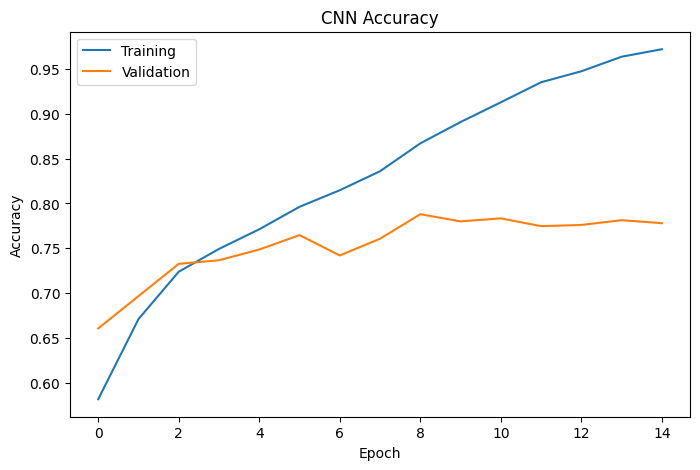

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

## Grafik Loss CNN

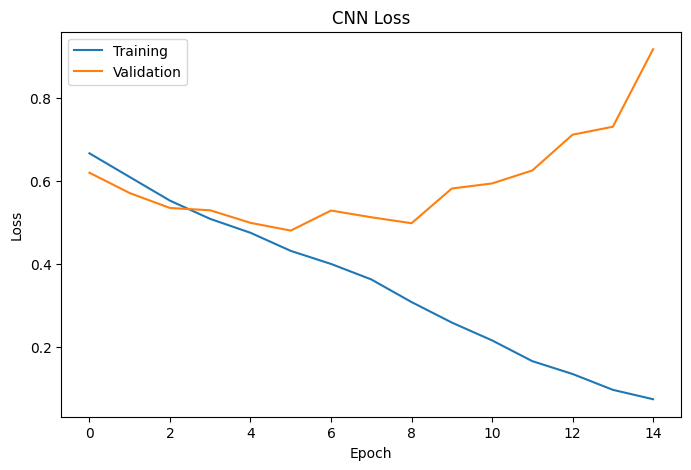

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

## Confusion Matrix CNN

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


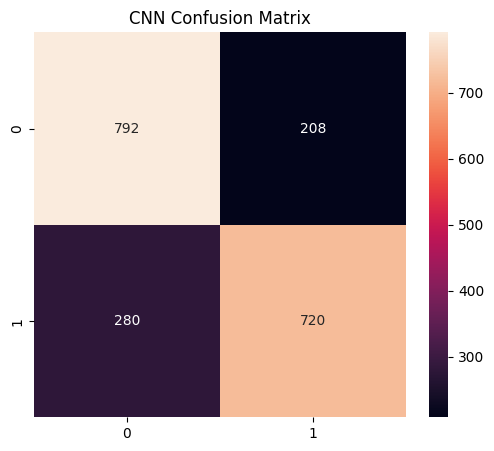

In [38]:
pred = cnn_model.predict(x_test)

pred_class = np.argmax(pred, axis=1)
true_class = np.argmax(y_test, axis=1)

cm = confusion_matrix(
    true_class,
    pred_class
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("CNN Confusion Matrix")
plt.show()

# Eksperimen 2 : Transfer Learning

Pada eksperimen kedua digunakan MobileNetV2 yang telah dilatih pada dataset ImageNet.

Strategi yang digunakan adalah Feature Extraction, yaitu membekukan seluruh layer pretrained model dan hanya melatih classifier baru.

In [39]:
!pip install -q kaggle

## Upload Kaggle API

Upload file:

kaggle.json

yang diperoleh dari akun Kaggle.

In [40]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"zahraarumsamudra","key":"c1ef85f2d06ddb2def44394eb1d83caa"}'}

In [41]:
!mkdir ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


## Download Dataset Cats vs Dogs

In [42]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
cat-and-dog.zip: Skipping, found more recently modified local copy (use --force to force download)


In [43]:
import zipfile

with zipfile.ZipFile(
    "cat-and-dog.zip",
    "r"
) as zip_ref:

    zip_ref.extractall("dataset")

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

train_data = train_gen.flow_from_directory(
    "dataset/training_set/training_set",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    "dataset/training_set/training_set",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 6805 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.


## MobileNetV2

In [45]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [46]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [47]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [48]:
history_transfer = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 189s 870ms/step - accuracy: 0.9703 - loss: 0.0837 - val_accuracy: 0.9850 - val_loss: 0.0444
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 181s 848ms/step - accuracy: 0.9837 - loss: 0.0434 - val_accuracy: 0.9858 - val_loss: 0.0386
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 180s 847ms/step - accuracy: 0.9884 - loss: 0.0339 - val_accuracy: 0.9842 - val_loss: 0.0437
Epoch 4/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 196s 920ms/step - accuracy: 0.9924 - loss: 0.0207 - val_accuracy: 0.9883 - val_loss: 0.0412
Epoch 5/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 187s 877ms/step - accuracy: 0.9950 - loss: 0.0139 - val_accuracy: 0.9867 - val_loss: 0.0424


In [49]:
transfer_loss, transfer_acc = transfer_model.evaluate(
    val_data
)

print("Transfer Accuracy :", transfer_acc)
print("Transfer Loss :", transfer_loss)

38/38 ━━━━━━━━━━━━━━━━━━━━ 29s 757ms/step - accuracy: 0.9867 - loss: 0.0424
Transfer Accuracy : 0.9866666793823242
Transfer Loss : 0.04244763031601906


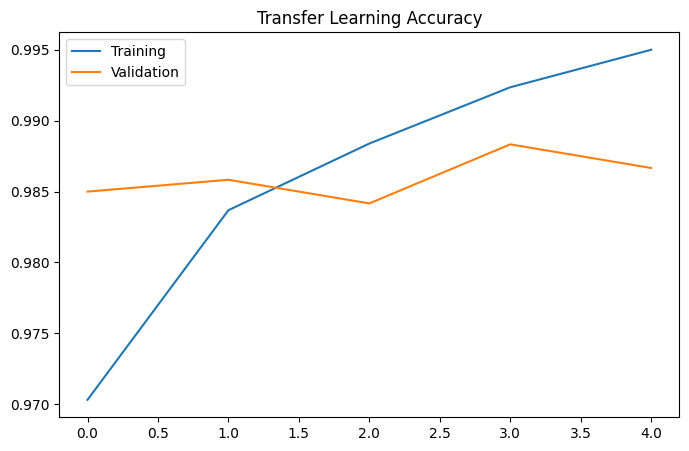

In [50]:
plt.figure(figsize=(8,5))

plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])

plt.title("Transfer Learning Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

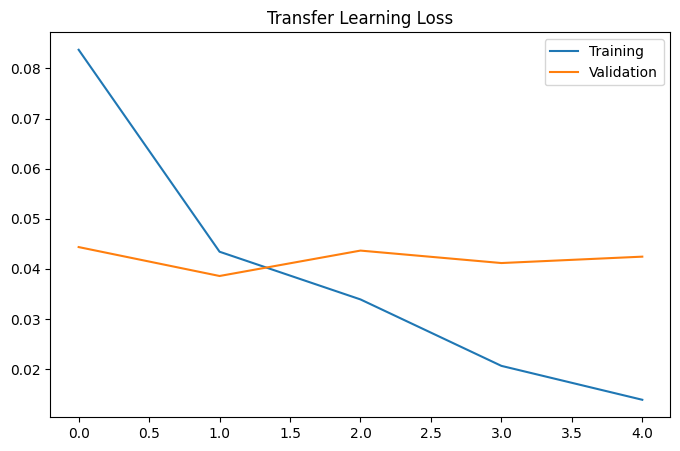

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history_transfer.history['loss'])
plt.plot(history_transfer.history['val_loss'])

plt.title("Transfer Learning Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

# Kesimpulan Sementara

Berdasarkan hasil eksperimen yang diperoleh, Transfer Learning menggunakan MobileNetV2 diharapkan menghasilkan akurasi yang lebih tinggi dan waktu training yang lebih cepat dibandingkan CNN From Scratch.

Hal ini terjadi karena MobileNetV2 telah mempelajari fitur-fitur visual dari jutaan gambar pada dataset ImageNet sehingga dapat digunakan kembali pada dataset baru dengan jumlah data yang lebih sedikit.